In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

In [2]:
df = pd.read_csv('iris.csv')
df["target"] = df["Species"].astype("category").cat.codes
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica,2
146,147,6.3,2.5,5.0,1.9,Iris-virginica,2
147,148,6.5,3.0,5.2,2.0,Iris-virginica,2
148,149,6.2,3.4,5.4,2.3,Iris-virginica,2


In [3]:
# Separar características de la etiqueta
X = df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]]
y = df["target"]

# Estandarizar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Instanciar y aplicar PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con las 2 nuevas dimensiones
df_pca = pd.DataFrame(data=X_pca, columns=["PCA 1", "PCA 2"])
df_pca["target"] = y

print(df_pca.head())

      PCA 1     PCA 2  target
0 -2.264542  0.505704       0
1 -2.086426 -0.655405       0
2 -2.367950 -0.318477       0
3 -2.304197 -0.575368       0
4 -2.388777  0.674767       0


In [5]:
varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA 1: {varianza[0]:.2%}")
print(f"Varianza explicada por PCA 2: {varianza[1]:.2%}")
print(f"Varianza total conservada: {sum(varianza):.2%}")

Varianza explicada por PCA 1: 72.77%
Varianza explicada por PCA 2: 23.03%
Varianza total conservada: 95.80%


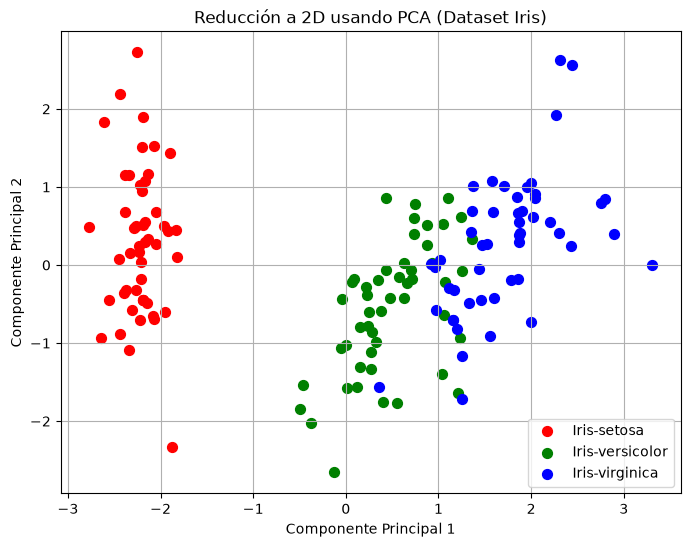

In [6]:
plt.figure(figsize=(8, 6))
targets = [0, 1, 2]
colors = ["red", "green", "blue"]

for target, color in zip(targets, colors):
    indices = df_pca["target"] == target
    plt.scatter(
        df_pca.loc[indices, "PCA 1"],
        df_pca.loc[indices, "PCA 2"],
        c=color,
        s=50,
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Reducción a 2D usando PCA (Dataset Iris)")
plt.legend(df["Species"].astype("category").cat.categories)
plt.grid(True)
plt.show()